## AutoLabel Demo: Thigh MRI Segmentation & Custom Aggregation

This notebook demonstrates how to quickly build and modify an AutoLabel configuration dictionary inline for rapid exploration with thigh MRI data. In this demo, key parameters—such as the input data directory, object detection model settings, and mask labels—are defined directly in the notebook. Additionally, the demo shows how to inject custom aggregation logic to handle overlapping masks (for example, by prioritizing specific labels or using prediction confidence), which can be useful when segmenting areas in close proximity. The interactive pipeline runs the AutoLabel process and displays both intermediate and final visualizations inline, allowing for immediate comparison of segmentation performance across different configurations.


In [ ]:
# ---
# Notebook Setup
# ---

import os
import sys
import copy
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# # Set the repository root to the parent folder, because this notebook is in demos/
REPO_ROOT = os.path.abspath("..")
print(REPO_ROOT)

os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

# Import the autolabel function from its module (located in src/obj_detection).
from src.obj_detection.autolabel import run_autolabel
from src.utils.visualization.preprocessing.segmentation_plots import plot_segmentation_overlay


/data/mskprojects/mskSAM/users/ghoyer/backup_repo/AutoMedLabel


In [2]:
import torch

if torch.cuda.is_available():
    print("CUDA is available.")
    print("Number of GPUs:", torch.cuda.device_count())
    print("Current GPU:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print("CUDA is not available.")


CUDA is available.
Number of GPUs: 1
Current GPU: Tesla V100-SXM3-32GB


In [3]:

def notebook_callback(action, **kwargs):
    if action == "plot_pred":
        # Receive the figure object and display it inline
        fig = kwargs.get("fig")
        if fig is not None:
            display(fig)
            plt.close(fig)  # ensure it's closed after display if needed
    if action == "plot_full":
        # Receive the figure object and display it inline
        fig = kwargs.get("fig")
        if fig is not None:
            display(fig)
            plt.close(fig)

def final_callback(image, mask, save_path, seg_clim, cmap, title, labels_dict):

    def slice_num(data, desired_slices):
        # find non-zero slices
        z_index, _, _ = np.where(data > 0)
        possible_inds = np.unique(z_index)

        num_slices = len(possible_inds)
        step_ = max(1, int(np.ceil(num_slices / desired_slices)))
        start = (num_slices % desired_slices) // 2 if num_slices > desired_slices else 0
        
        return possible_inds[range(start, num_slices, step_)]
    
    slices = slice_num(mask, desired_slices=24)
    fig = plot_segmentation_overlay(vol= image[slices,:,:], 
                        seg= mask[slices,:,:], 
                        save_path=save_path, 
                        seg_clim=seg_clim, 
                        cmap='rainbow', 
                        title="Thigh Muscle Example", #title, 
                        labels_dict=labels_dict,
                        ) 
    if fig is not None:
        display(fig)
        plt.close(fig)


In [ ]:

# Base configuration as a Python dictionary.
base_config = {
    "data": {
        "data_dir": "",
        "mask_labels": {
            0: "background",
        },
    },
    "output_cfg": {
        "base_output_dir": "work_dir/inference",
        "task_name": "mskSAM",
        "output_ext": "nii.gz",
        "visualize": True, #False, 
        "img_clim": False, #True,
        "desired_visuals": 1, 
        "logging_level": "DEBUG",
        "save_method": "nibabel",
    },
    "preprocessing_cfg": {
        "image_size": 1024,
        "voxel_num_thre2d": 100,
        "voxel_num_thre3d": 200,
        "remove_label_ids": [2],
        "instance_bbox": True,
        "make_square": True, 
        "use_sitk": False,
    },
    "device": "cuda:0",
    "models": {
        "obj_det": {
            "model_path": "",
            "model_weights": "",
            "model_type": "YOLO",
            "conf": 0.25,
            "post_processing": True,
        },
        "segmentation": {
            "finetuned_model": "/data/mskprojects/mskSAM/users/ghoyer/mskSam/work_dir/model_weights/Finetuned/Muscle/no_aug_bbox_shift_0/not_balanced/img_enc_True/early_stop_patience_10/subject_full/20240530-0438_finetuned_model_best.pth", 
            "model_identifier": "mixed_Muscle_best_no_shift",
            "pretrain_model": "work_dir/model_weights/SAM/sam_vit_b_01ec64.pth", 
            "model_type": "vit_b", 
            "model_details": {
                "balanced": False,
                "subject": "full",
                "bbox_shift": 0,
            },
            "trainable": {
                "prompt_encoder": False,
                "image_encoder": True,
                "mask_decoder": True,
                "resize_masks": True,
            },
        },
    },
}

# Define a list of cases with the fields to override.
cases = [
    {
        "data_dir": "../misc_examples/Thigh_2D_T1ax_Clinical_Anatomical_50.nii.gz", 
        "img_clim": False, #True,
        "obj_det_model_path": "/data/mskprojects/mskSAM/users/ghoyer/AutoMedLabel2/work_dir/obj_detection/OAI_Thigh/runs/train3/weights/best.pt",
        "obj_det_model_weights": "thight1ax_YOLO8",
        "mask_labels": {
            0: "background",
            1: "sc_fat",
            2: "fascia",
            3: "extensors",
            4: "hamstrings",
            5: "fem_cortex",
            6: "fem_bm",
            7: "adductors",
            8: "sartorius",
            9: "gracilis",
            10: "nv",
        },
    },
]


In [5]:
# def my_custom_agg(combined_mask, confidence_map, new_mask, new_conf, label_id, mask_labels):
#     # Example: Always prioritize label 1 regardless of confidence, then use confidence for others.
#     if label_id == 1:
#         update_indices = (new_mask > 0)
#     else:
#         update_indices = (new_mask > 0) & (confidence_map < new_conf)
#     combined_mask[update_indices] = label_id
#     confidence_map[update_indices] = new_conf
#     return combined_mask, confidence_map


  0%|          | 0/1 [00:00<?, ?it/s]

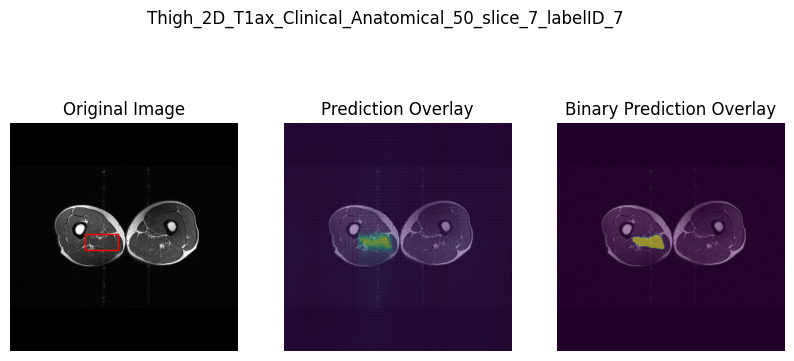

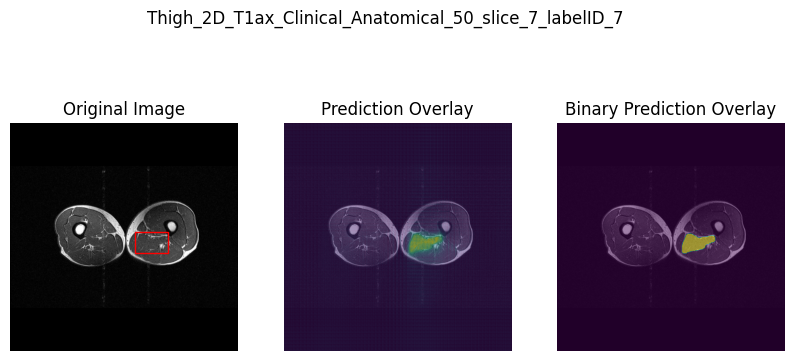

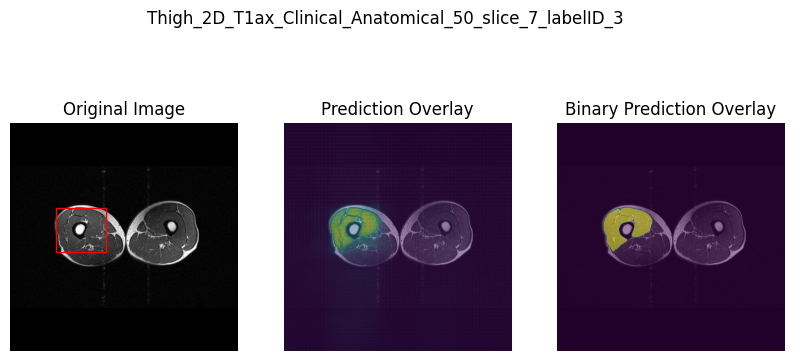

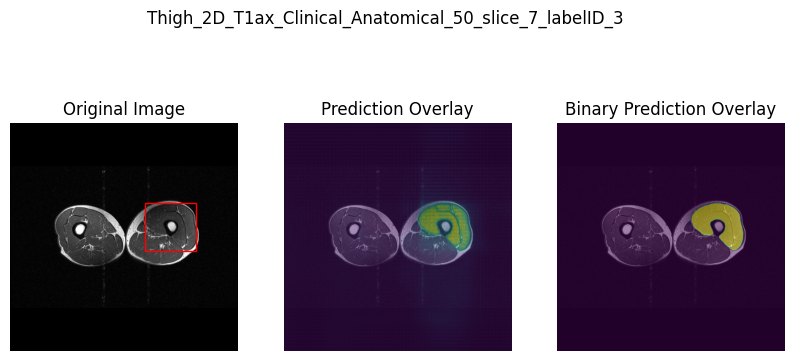

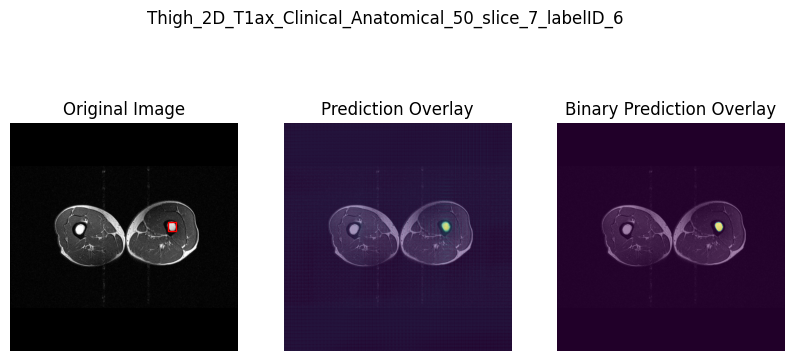

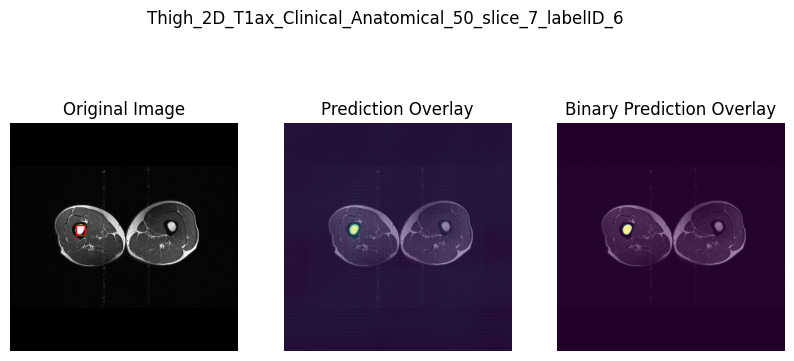

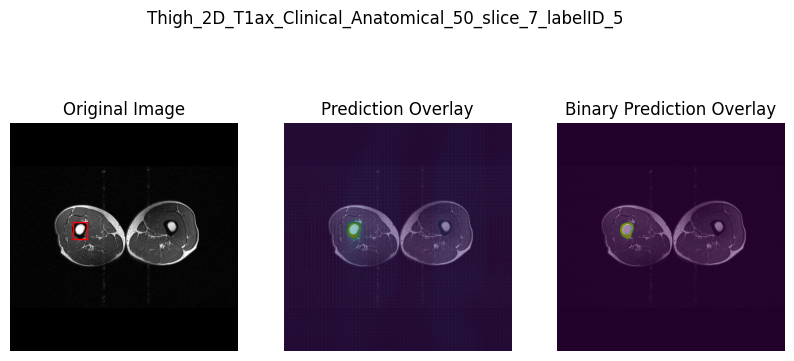

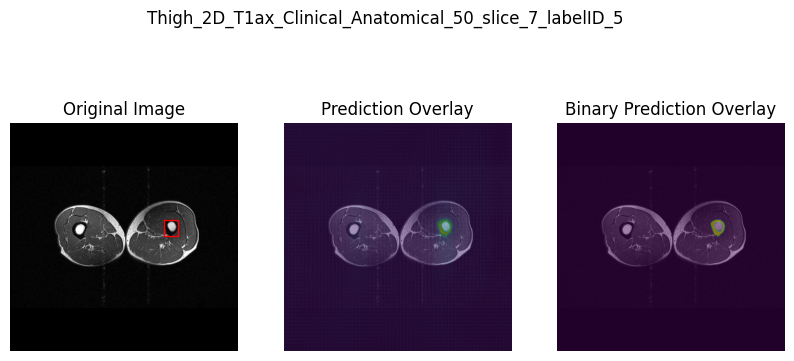

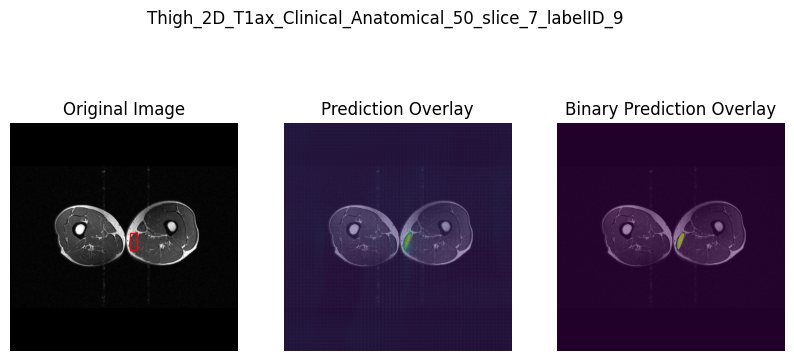

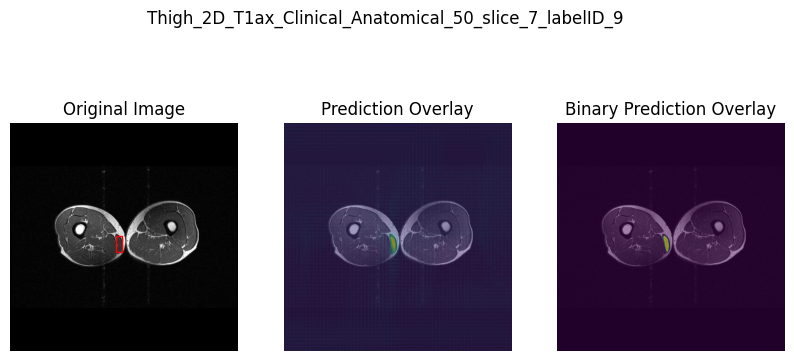

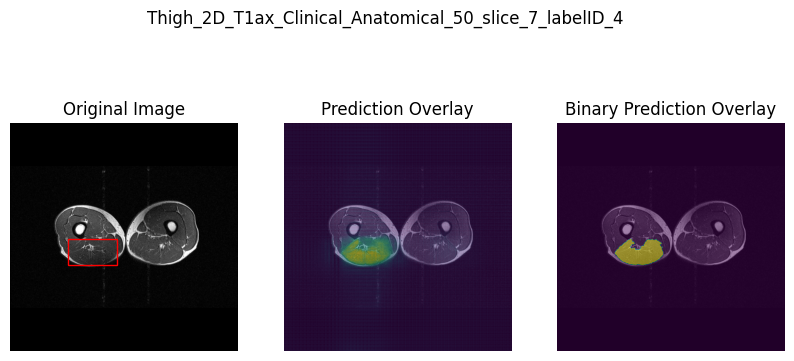

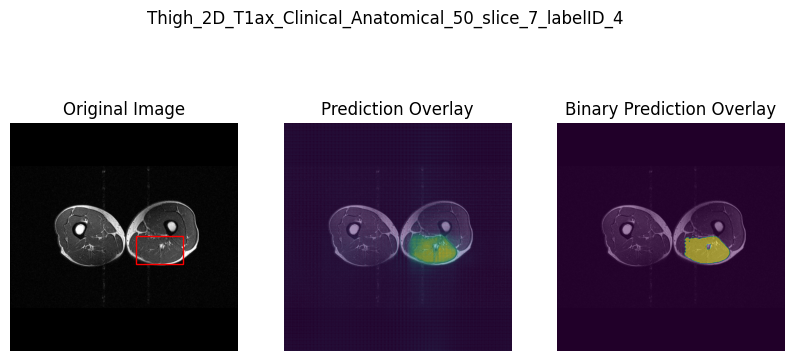

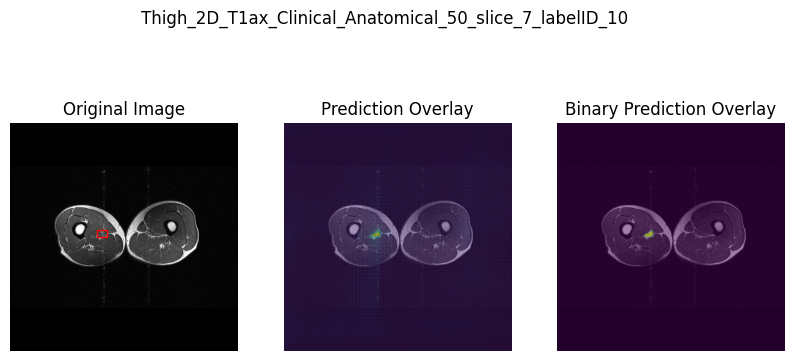

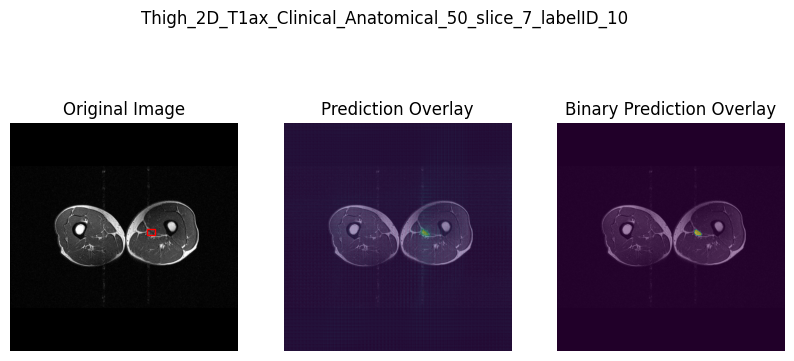

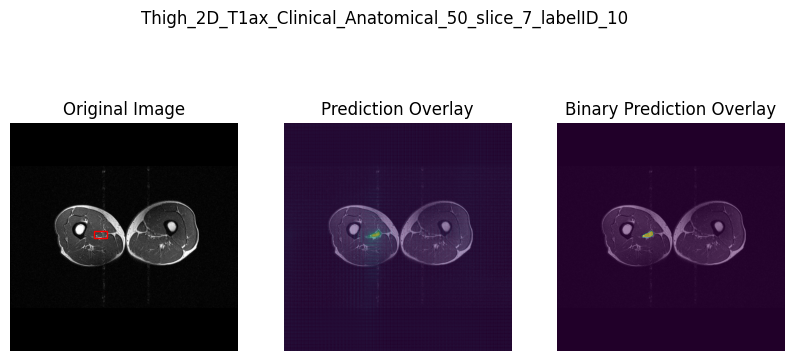

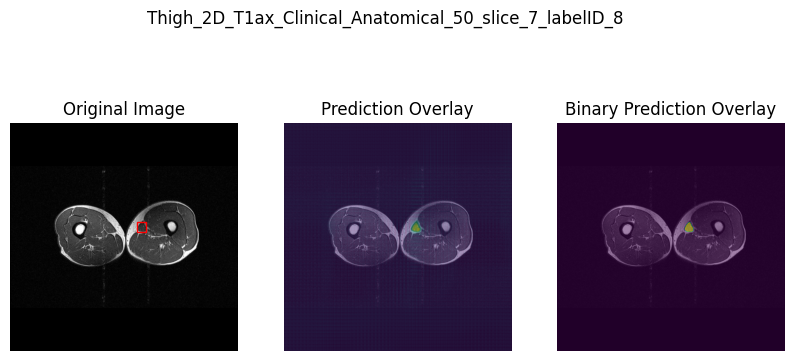

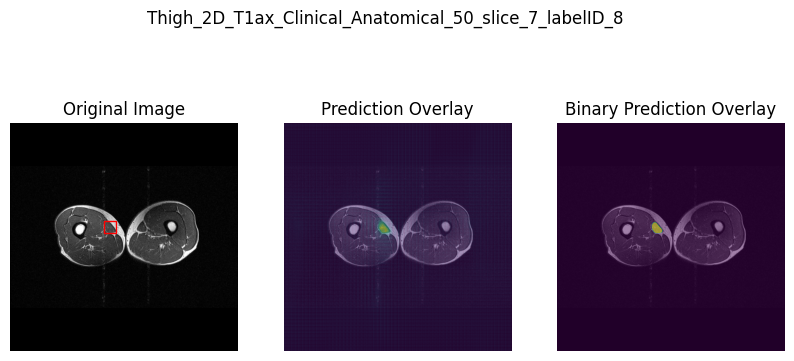

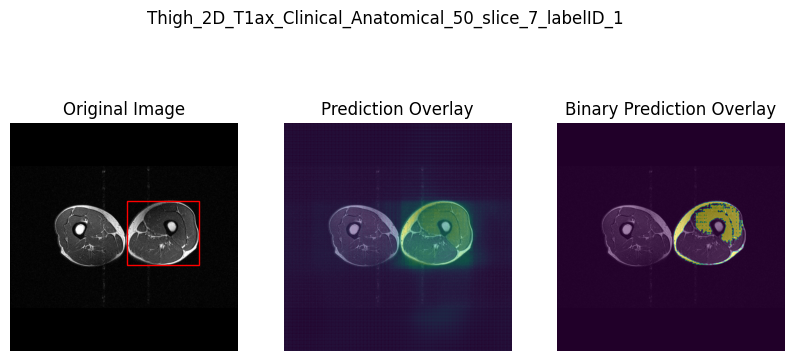

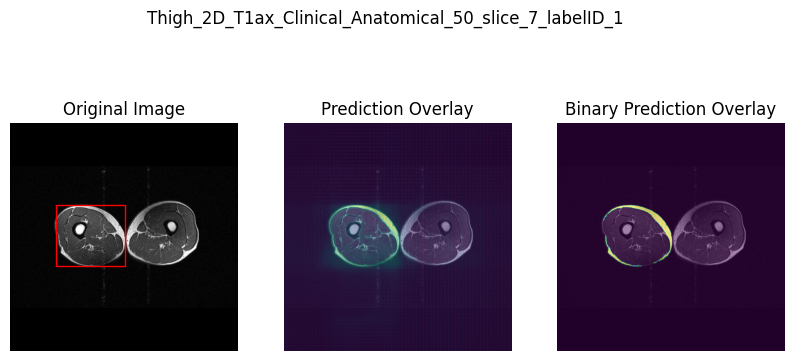

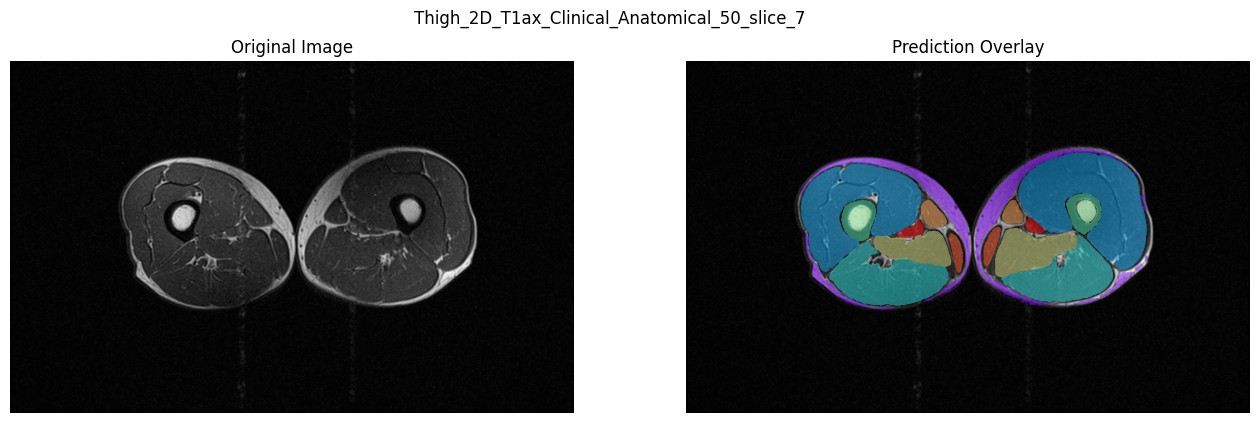

returning fig from plot_segmentation_overlay


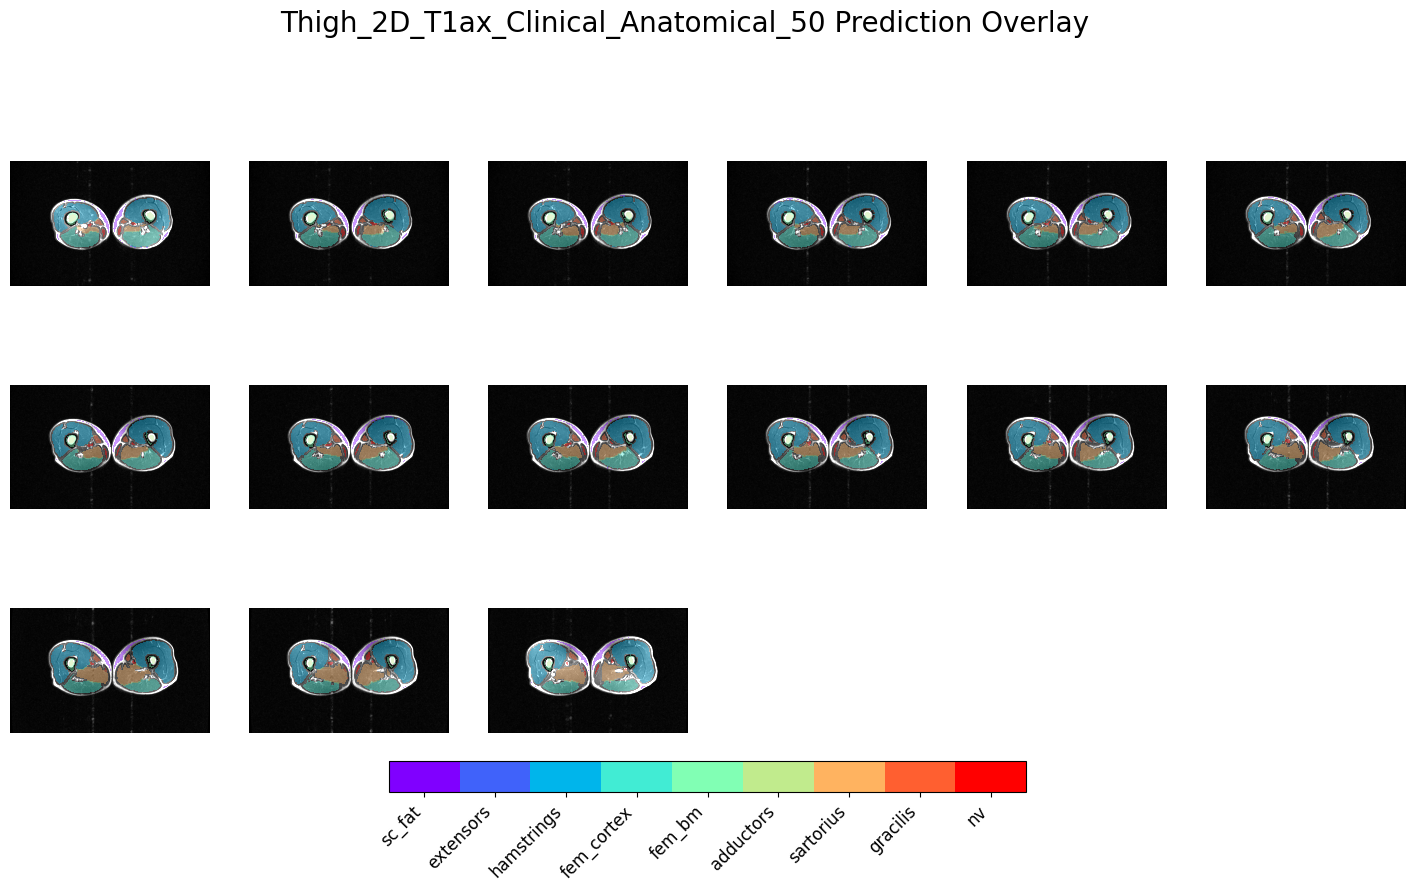

100%|██████████| 1/1 [01:00<00:00, 60.59s/it]


In [ ]:

# Loop over each case, adjust the config, and run the process.
for case in cases:
    # Create a deep copy of the base configuration.
    config_copy = copy.deepcopy(base_config)
    
    # Update the data directory.
    config_copy["data"]["data_dir"] = case["data_dir"]
    
    # Update the output configuration for image color limits and task name.
    config_copy["output_cfg"]["img_clim"] = case["img_clim"]
    config_copy["output_cfg"]["task_name"] = f"Knee_{os.path.basename(case['data_dir'])}"
    
    # Update the object detection model fields.
    config_copy["models"]["obj_det"]["model_path"] = case["obj_det_model_path"]
    config_copy["models"]["obj_det"]["model_weights"] = case["obj_det_model_weights"]
    
    # Update the mask labels.
    config_copy["data"]["mask_labels"] = case["mask_labels"]
    
    # Run the autolabel process with the modified config.
    run_autolabel(config_copy, interactive=True, callback=notebook_callback, final_callback=final_callback)

    
    # # Call run_autolabel with custom aggregation function:
    # run_autolabel(config_copy, interactive=True, callback=notebook_callback,
    #             final_callback=final_callback, agg_callback=my_custom_agg)
